#Linear Regression

## Linear Regression

Linear regression is a supervised learning algorithm that models the relationship between a dependent variable and one or more independent variables by fitting a linear equation to the observed data.

### 1. Linear Regression Implementation
* Implementing a linear regression model optimized by gradient descent or the closed-form approach presented in the lecture using `numpy` only. Use the `LinearRegression` class structure below. Especially, when using the closed-form, beware of numeric stability issues.
* Evaluating the performance by using appropriate metrics for the [AUTO MPG](https://archive.ics.uci.edu/dataset/9/auto+mpg) dataset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import requests, zipfile, io

In [ ]:
class LinearRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))

        for i in range(self.n_iterations):
            y_pred = X.dot(self.weights)
            error = y_pred - y
            gradients = (1/n_samples) * X.T.dot(error)
            self.weights -= self.learning_rate * gradients

            # Mean Squared Error Loss
            loss = (1/(2*n_samples)) * np.sum(error**2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        return X.dot(self.weights)

/tmp/ipython-input-2057799805.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("auto_mpg_data/auto-mpg.data", delim_whitespace=True, header=None,


(RESULT) Mean Squared Error: 0.17877984486032672
(RESULT) R² Score: 0.8212201551396733


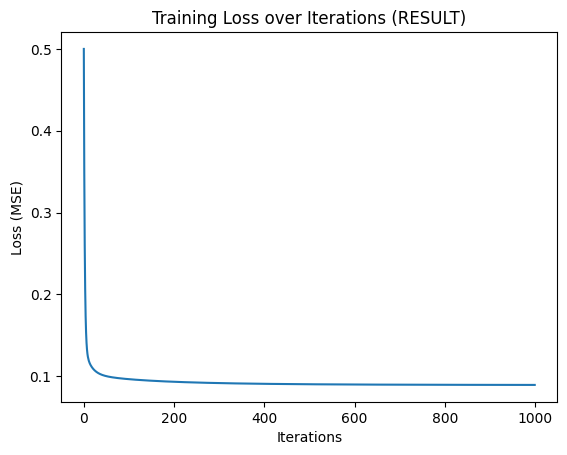

In [ ]:
# Get AUTO MPG dataset
url = "https://archive.ics.uci.edu/static/public/9/auto+mpg.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("auto_mpg_data")

df = pd.read_csv("auto_mpg_data/auto-mpg.data", delim_whitespace=True, header=None,
                 names=["mpg","cylinders","displacement","horsepower","weight",
                        "acceleration","model_year","origin","car_name"],
                 na_values='?')
#Preprocessing
df = df.dropna()
df = df.drop(columns=['car_name'])

X = df.drop(columns=['mpg']).values
y = df['mpg'].values.reshape(-1, 1)

# Normalize (important for gradient descent stability)
X = (X - X.mean(axis=0)) / X.std(axis=0)
y = (y - y.mean()) / y.std()


X = np.c_[np.ones((X.shape[0], 1)), X] #bias term

#Training
model = LinearRegression(learning_rate=0.05, n_iterations=1000)
model.fit(X, y)
#Evaluation
y_pred = model.predict(X)
mse = np.mean((y - y_pred)**2)
r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - np.mean(y))**2)

print("(RESULT) Mean Squared Error:", mse)
print("(RESULT) R² Score:", r2)

plt.plot(range(len(model.loss_history)), model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss over Iterations (RESULT)")
plt.show()


##Polynomial Regression

Transform features into polynomial terms (x, x², x³) to fit non-linear relationships.

* Implementing a feature transformation step before feeding to the linear model.
* Comparing the performance of the polynomial regression model (degree 2 and 3) with the linear model on the [AUTO MPG](https://archive.ics.uci.edu/dataset/9/auto+mpg) dataset.


In [ ]:
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import requests, zipfile, io

(RESULT) Linear (Degree 1): MSE=0.1788, R²=0.8212
(RESULT) Polynomial (Degree 2): MSE=0.1066, R²=0.8934
(RESULT) Polynomial (Degree 3): MSE=0.1118, R²=0.8882


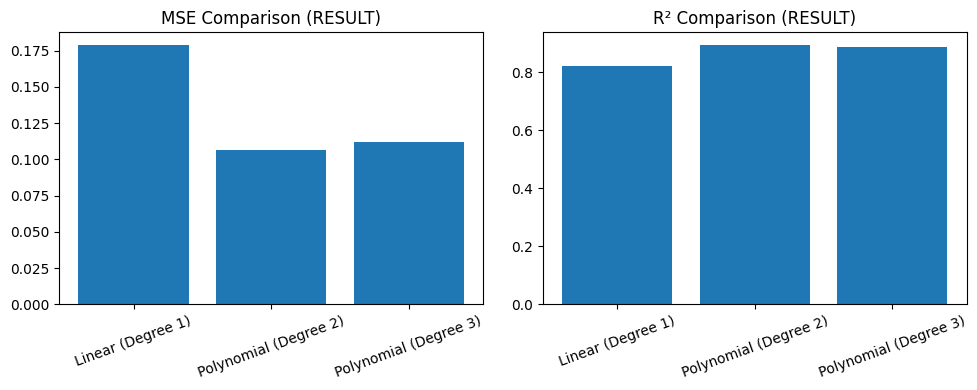

In [ ]:
url = "https://archive.ics.uci.edu/static/public/9/auto+mpg.zip"
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("auto_mpg_data")

df = pd.read_csv(
    "auto_mpg_data/auto-mpg.data",
    sep=r"\s+",
    header=None,
    names=["mpg","cylinders","displacement","horsepower","weight",
           "acceleration","model_year","origin","car_name"],
    na_values="?"
)
df = df.dropna().drop(columns=["car_name"])
X_raw = df.drop(columns=["mpg"]).values.astype(float)
y_raw = df["mpg"].values.reshape(-1, 1).astype(float)

# Standardize features and target for stability
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
y = (y_raw - y_raw.mean()) / y_raw.std()


class PolynomialFeatures:
    def __init__(self, degree=2):
        self.degree = degree
        self.powers = None

    def fit(self, X):
        n_features = X.shape[1]
        self.powers = []
        for d in range(self.degree + 1):
            for comb in itertools.combinations_with_replacement(range(n_features), d):
                self.powers.append(comb)
        return self

    def transform(self, X):
        n_samples = X.shape[0]
        X_poly = np.ones((n_samples, len(self.powers)))
        for i, comb in enumerate(self.powers):
            if len(comb) == 0:
                X_poly[:, i] = 1.0
            else:
                X_poly[:, i] = np.prod(X[:, comb], axis=1)
        return X_poly

    def fit_transform(self, X):
        return self.fit(X).transform(X)

class PolynomialRegression:
    def __init__(self, degree=2, learning_rate=0.01, n_iterations=1000):
        self.degree = degree
        self.poly = PolynomialFeatures(degree=degree)
        self.lr = LinearRegression(learning_rate=learning_rate, n_iterations=n_iterations)
        self.mean_ = None
        self.std_ = None

    def fit(self, X, y):
        Xp = self.poly.fit_transform(X)
        self.mean_ = Xp.mean(axis=0)
        self.std_ = Xp.std(axis=0) + 1e-8
        Xp = (Xp - self.mean_) / self.std_
        self.lr.fit(Xp, y)
        return self

    def predict(self, X):
        Xp = self.poly.transform(X)
        Xp = (Xp - self.mean_) / self.std_
        return self.lr.predict(Xp)

models = {
    "Linear (Degree 1)": PolynomialRegression(degree=1, learning_rate=0.05, n_iterations=1000),
    "Polynomial (Degree 2)": PolynomialRegression(degree=2, learning_rate=0.02, n_iterations=1500),
    "Polynomial (Degree 3)": PolynomialRegression(degree=3, learning_rate=0.001, n_iterations=2000),
}

results = {}
for name, mdl in models.items():
    mdl.fit(X, y)
    yhat = mdl.predict(X)
    mse = np.mean((y - yhat) ** 2)
    r2 = 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    results[name] = (mse, r2)
    print(f"(RESULT) {name}: MSE={mse:.4f}, R²={r2:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
names = list(results.keys())
mse_vals = [results[k][0] for k in names]
r2_vals = [results[k][1] for k in names]
ax[0].bar(names, mse_vals); ax[0].set_title("MSE Comparison (RESULT)"); ax[0].tick_params(axis="x", rotation=20)
ax[1].bar(names, r2_vals); ax[1].set_title("R² Comparison (RESULT)"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
